In [1]:
import collections
import copy
import functools
import glob
import operator
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf

from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import mixture
from sklearn import datasets
from tqdm import tqdm

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)

In [2]:
DATA_FOLDER = "../data"
FEATURE_IMPORTANCE_DATA_FOLDER = os.path.join(DATA_FOLDER, "./Feature_Importance_Data")
FIGURES_FOLDER = "../figures"

# List files available

In [3]:
FEATURE_IMPORTANCE_FNAME_ARRAY = sorted(os.listdir(FEATURE_IMPORTANCE_DATA_FOLDER))
FEATURE_IMPORTANCE_FNAME_ARRAY

['VTOP40_113.csv',
 'VTOP40_128.csv',
 'VTOP40_143.csv',
 'VTOP40_158.csv',
 'VTOP40_173.csv',
 'VTOP40_188.csv',
 'VTOP40_203.csv',
 'VTOP40_218.csv',
 'VTOP40_233.csv',
 'VTOP40_300.csv',
 'VTOP40_346.csv',
 'VTOP40_400.csv',
 'VTOP40_500.csv',
 'VTOP40_550.csv',
 'VTOP40_578.csv',
 'VTOP40_593.csv',
 'VTOP40_68.csv',
 'VTOP40_83.csv',
 'VTOP40_98.csv']

In [4]:
cutoffs_chosen = [346,578]

In [5]:
def plot_var_importance(cutoff):

    df = pd.read_csv(os.path.join(FEATURE_IMPORTANCE_DATA_FOLDER,"VTOP40_{}.csv".format(cutoff)))
    #df.loc[1,"Vnames"] = "Time Index"
    derived_features = ["r.lm","t0.lm","cutoff"]
    df = df[~df["Vnames"].isin(derived_features)]
    Top10 = df.loc[:10,"Importance (%)"].sum()
    fig = df.iloc[:10].plot.barh(x="Vnames",y="Importance (%)", figsize=(10,10), title="Top 10 Most Important Variables Day {} consisting {:.2f}%".format(cutoff,Top10)).get_figure()
    fig.savefig(os.path.join(FIGURES_FOLDER,"VTOP40_{}_plot.png".format(cutoff)), bbox_inches = "tight")
    return df

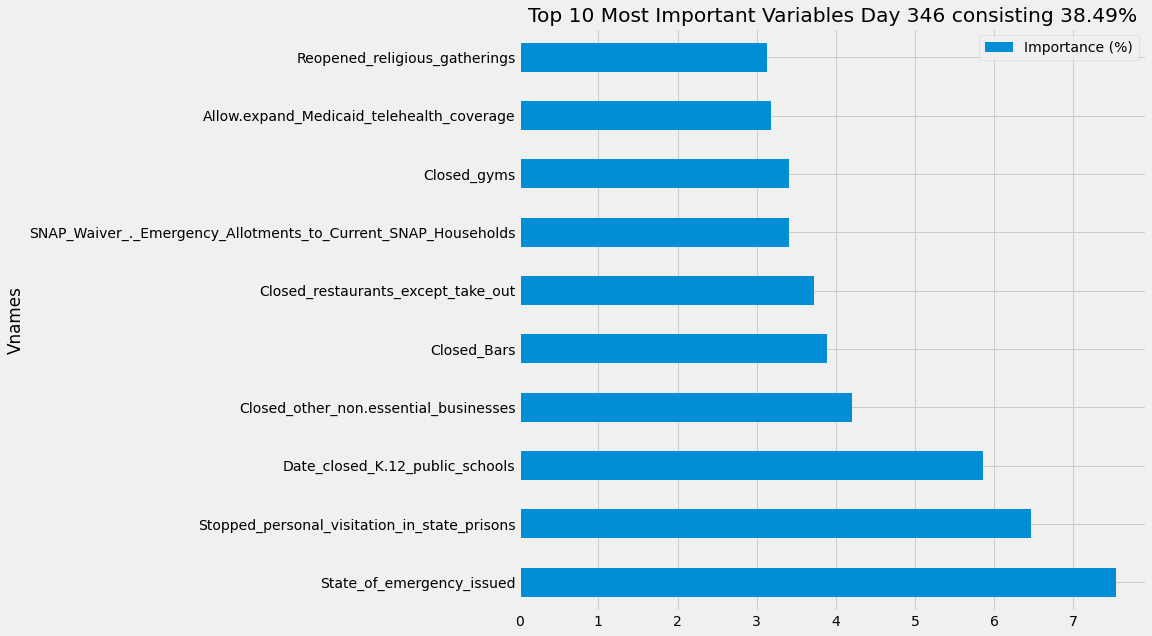

In [6]:
df1= plot_var_importance(cutoffs_chosen[0])

In [7]:
#df1.loc[:10,"Importance (%)"].sum()

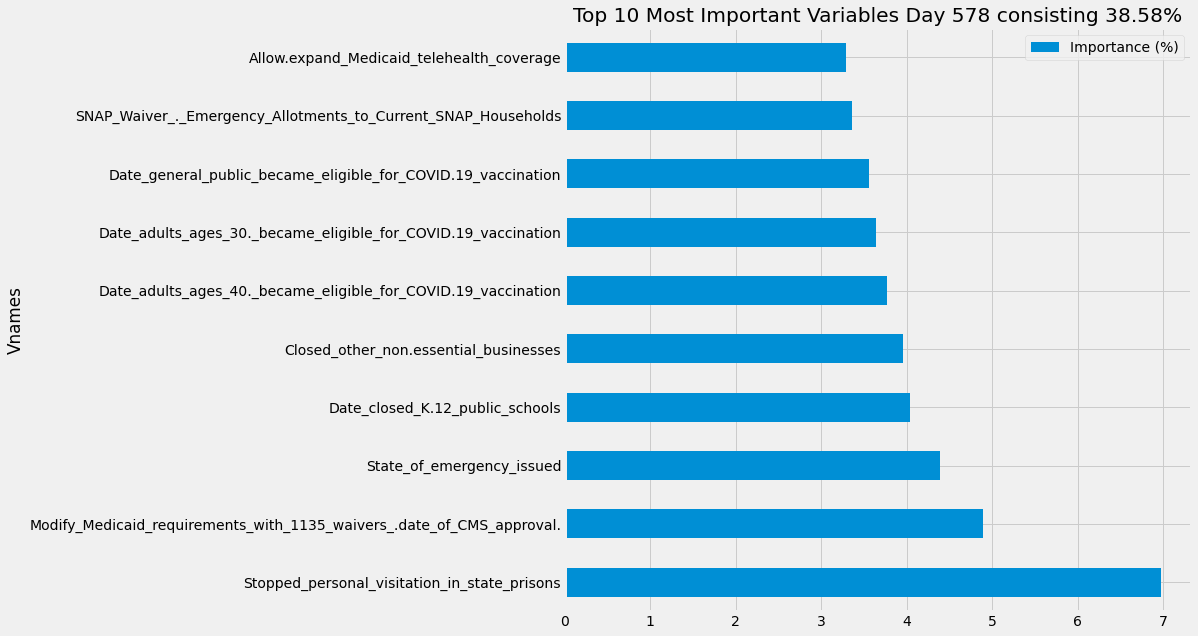

In [8]:
df2 = plot_var_importance(cutoffs_chosen[1])

In [35]:
def plot_all(arr):
    def combine_dicts(a, b, op=operator.add):
        return dict(a.items() + b.items() + [(k, op(a[k], b[k])) for k in set(b) & set(a)])
    derived_features = ["r.lm","t0.lm","cutoff"]
    acc_dict = collections.defaultdict(float)
    grand_total = 0
    for fname in arr:
        test_df = pd.read_csv(os.path.join(FEATURE_IMPORTANCE_DATA_FOLDER,fname))
        test_df = test_df[~test_df["Vnames"].isin(derived_features)]
        test_df = test_df[["Vnames","Importance"]]
        test_dict = dict(zip(test_df["Vnames"],test_df["Importance"]))
        total = 0
        for key, value in test_dict.items():
            total += value
        for key, value in test_dict.items():
            acc_dict[key] += value/total
        grand_total += 1
            
    #df.loc[1,"Vnames"] = "Time Index"
    
    #Top10 = df.loc[:10,"Importance (%)"].sum()
    #fig = df.iloc[:10].plot.barh(x="Vnames",y="Importance (%)", figsize=(10,10), title="Top 10 Most Important Variables Day {} consisting {:.2f}%".format(cutoff,Top10)).get_figure()
    #fig.savefig(os.path.join(FIGURES_FOLDER,"VTOP40_{}_plot.png".format(cutoff)), bbox_inches = "tight")
    
    for key, value in acc_dict.items():
        acc_dict[key] = value/grand_total * 100
    
    acc_df = pd.DataFrame({"Features":acc_dict.keys(), "Importance (%)":acc_dict.values()})
    acc_df = acc_df.sort_values(by="Importance (%)",ascending=False)
    acc_df = acc_df.reset_index(drop=True)
    Top10 = acc_df.loc[:10,"Importance (%)"].sum()

    acc_df.loc[0,"Features"] = "Date closed K-12 public schools"
    acc_df.loc[1,"Features"] = "Expanding Supplemental Nutrition Assistance Program (SNAP)"
    acc_df.loc[2,"Features"] = "State of emergency issued"
    acc_df.loc[3,"Features"] = "Stopped personal visitation in state prisons"
    acc_df.loc[4,"Features"] = "Date general public became eligible for vaccination"
    acc_df.loc[5,"Features"] = "Expand Medicaid benefits (1135 Waiver)"
    acc_df.loc[6,"Features"] = "Date adults ages 40+ became eligible for vaccination"
    acc_df.loc[7,"Features"] = "Date adults ages 30+ became eligible for vaccination"
    acc_df.loc[8,"Features"] = "Closed other non-essential businesses"
    acc_df.loc[9,"Features"] = "Closed bars"


    fig = acc_df.iloc[:10].plot.barh(x="Features",y="Importance (%)", figsize=(12,12)).get_figure()
    fig.savefig(os.path.join(FIGURES_FOLDER,"Aggregated_Top10.png"), bbox_inches = "tight")
    acc_df["Notes"] = "Placeholder"
    return acc_df

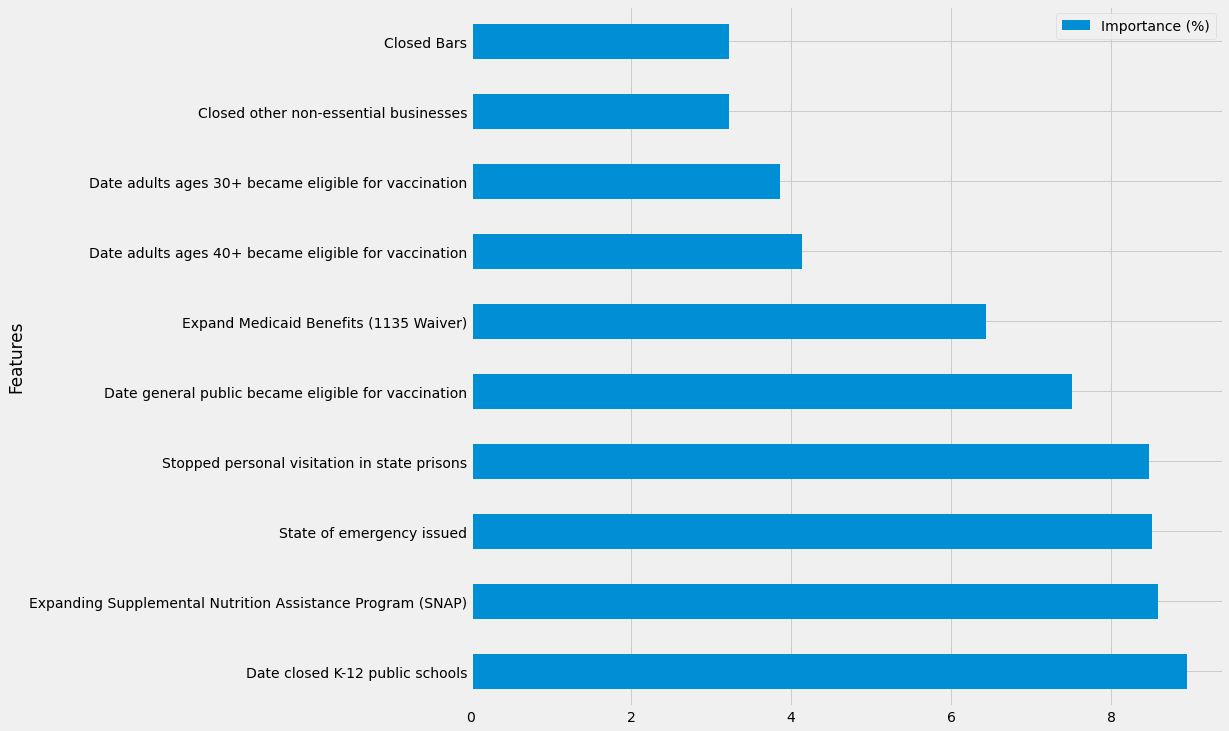

In [36]:
acc_df = plot_all(FEATURE_IMPORTANCE_FNAME_ARRAY)
#acc_df

In [37]:
acc_df = acc_df.reset_index(drop=True)
acc_df.loc[0,"Notes"] = 0
acc_df.loc[1,"Notes"] = 2
acc_df.loc[2,"Notes"] = 0
acc_df.loc[3,"Notes"] = 0
acc_df.loc[4,"Notes"] = 1
acc_df.loc[5,"Notes"] = 2
acc_df.loc[6,"Notes"] = 1
acc_df.loc[7,"Notes"] = 1
acc_df.loc[8,"Notes"] = 0
acc_df.loc[9,"Notes"] = 0
acc_df = acc_df.iloc[:10]
acc_df

,Features,Importance (%),Notes
0,Date closed K-12 public schools,8.939269,0
1,Expanding Supplemental Nutrition Assistance Pr...,8.579343,2
2,State of emergency issued,8.507281,0
3,Stopped personal visitation in state prisons,8.465524,0
4,Date general public became eligible for vaccin...,7.507873,1
5,Expand Medicaid Benefits (1135 Waiver),6.428172,2
6,Date adults ages 40+ became eligible for vacci...,4.138379,1
7,Date adults ages 30+ became eligible for vacci...,3.864200,1
8,Closed other non-essential businesses,3.224243,0
9,Closed Bars,3.222920,0


In [12]:
acc_df[acc_df["Notes"]==0].sum(), acc_df[acc_df["Notes"]==1].sum(), acc_df[acc_df["Notes"]==2].sum()

(Features          Date closed K-12 public schoolsState of emerge...
 Importance (%)                                            32.359238
 Notes                                                             0
 dtype: object,
 Features          Date general public became eligible for vaccin...
 Importance (%)                                            15.510452
 Notes                                                             3
 dtype: object,
 Features          Expanding Supplemental Nutrition Assistance Pr...
 Importance (%)                                            15.007515
 Notes                                                             4
 dtype: object)

In [13]:
codebook_path = os.path.join(DATA_FOLDER,"Codebook_Formatted.csv")
if not os.path.isfile(codebook_path):
    codebook = pd.read_csv(os.path.join(DATA_FOLDER,"Codebook.csv"),encoding = 'unicode_escape')
    codebook = codebook.loc[:285]
    codebook = codebook[codebook.columns[:9]]
    codebook.to_csv(codebook_path,index=False)
else:
    codebook = pd.read_csv(codebook_path)

In [14]:
codebook = codebook[["Variable Name","Variable Label", "Description"]]
codebook

,Variable Name,Variable Label,Description
0,STATE,State,US State names
1,POSTCODE,State Abbreviation,US State abbreviations
2,FIPS,FIPS Code,US State FIPS Codes
3,STEMERG,State of emergency issued,The date a state first issued any type of emer...
4,STEMERGEND,State of emergency lifted,The date a state allowed its emergency declara...
...,...,...,...
281,MINWAGESEP2020,Sep 1 2020 Minimum Wage,The hourly minimum wage in each state as of Se...
282,MINWAGEOCT2020,Oct 1 2020 Minimum Wage,The hourly minimum wage in each state as of Oc...
283,TIPMINWAGE2020,2020 Minimum Wage for Tipped Workers,The hourly minimum wage for tipped workers in ...
284,MINWAGE2021,2021 Minimum Wage,The hourly minimum wage in each state in 2021....


In [15]:
Top10VariableNames = []
Top10VariableNames.append("CLSCHOOL")
Top10VariableNames.append("SNAPALLO")
Top10VariableNames.append("STEMERG")
Top10VariableNames.append("VISITPER")
Top10VariableNames.append("PUBDATE")
Top10VariableNames.append("MED1135W")
Top10VariableNames.append("40DATE")
Top10VariableNames.append("30DATE")
Top10VariableNames.append("CLBSNS")
Top10VariableNames.append("CLOSEBAR")
len(Top10VariableNames)

10

In [16]:
Top10NamesDf = pd.DataFrame({"Variable Name":Top10VariableNames})
Top10Codebook = pd.merge(left=Top10NamesDf,right=codebook,how="left")
Top10Codebook

,Variable Name,Variable Label,Description
0,CLSCHOOL,Date closed K-12 public schools,The date a state closed K-12 public schools st...
1,SNAPALLO,SNAP Waiver - Emergency allotments to current ...,The date a state was approved the use of a wai...
2,STEMERG,State of emergency issued,The date a state first issued any type of emer...
3,VISITPER,Stopped personal visitation in state prisons,The date personal visitation was banned at pri...
4,PUBDATE,Date general public became eligible for vaccin...,The date in which a state made the general pub...
5,MED1135W,Modify Medicaid requirements with 1135 waivers...,The date a state used a 1135 waiver to modify ...
6,40DATE,Date adults ages 40+ became eligible for vacci...,The date in which a state made adults ages 40+...
7,30DATE,Date adults ages 30+ became eligible for vacci...,The date in which a state made adults ages 30+...
8,CLBSNS,Closed other non-essential businesses,The date a state closed non-essential business...
9,CLOSEBAR,Closed Bars,The date states closed bars statewide. Unless ...


In [17]:
with open(os.path.join(FIGURES_FOLDER,"VTOP10.txt"), "w") as f:
    with pd.option_context("max_colwidth", 1000):
        print(Top10Codebook[["Variable Label","Description"]].to_latex(index=False,column_format='p{4cm}|p{12cm}'
), file=f)


In [18]:
test_df = pd.read_csv(os.path.join(FEATURE_IMPORTANCE_DATA_FOLDER,"VTOP40_98.csv"))
test_dict = dict(zip(test_df["Vnames"],test_df["Importance"]))

In [19]:
for index, row in test_df.iterrows():
    print(k)

NameError: name 'k' is not defined

In [ ]:
collections.defaultdict(float)

defaultdict(float, {})

In [ ]:
operator.add

<function _operator.add(a, b, /)>